torch.Size([32, 3, 128, 128])


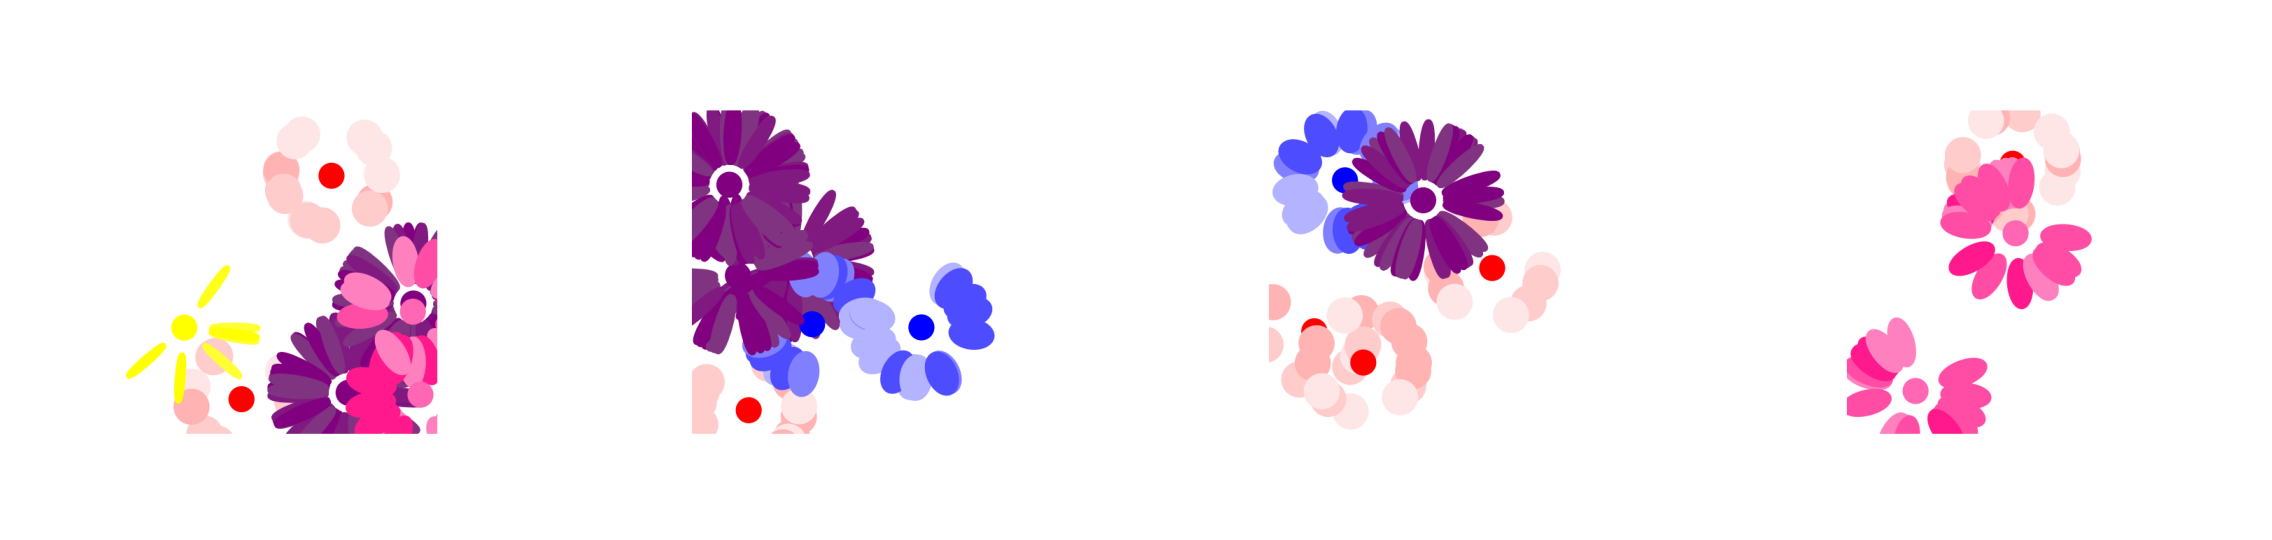

In [ ]:
import torch
import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# -- Configuration with added complexity --
# Gamma-Poisson parameters
alpha = 2.75
beta = 0.8
# Center types and their RGB colors
center_types = ['red', 'blue', 'pink', 'purple', 'yellow']
center_rgb = {
    'red':    (1.0, 0.0, 0.0),
    'blue':   (0.0, 0.0, 1.0),
    'pink':   (1.0, 0.4, 0.7),
    'purple': (0.5, 0.0, 0.5),
    'yellow': (1.0, 1.0, 0.0)
}

# Mean petal counts by center type
r_k = {'red': 12, 'blue': 20, 'pink': 15, 'purple': 50, 'yellow': 10 }

# Petal saturation options vary by flower type (PC_{ij}|C_i)
petal_saturation_options = {
    'red':    [0.1, 0.2, 0.3],   # very pale
    'blue':   [0.3, 0.5, 0.7],   # medium pale
    'pink':   [0.5, 0.7, 0.9],   # somewhat darker
    'purple': [0.6, 0.8, 1.0],   # dark
    'yellow': [0.8, 0.9, 1.0]    # darkest options only
}

# Petal shape ratios vary by flower type (height-width)
petal_shape = {
    'red':    {'width': 6,  'height': 6},   # round
    'blue':   {'width': 8,  'height': 5},   # slightly elliptical
    'pink':   {'width': 9,  'height': 4},   # more elongated
    'purple': {'width': 11, 'height': 2},   # skinny
    'yellow': {'width': 9, 'height': 1}    # very skinny
}


def generate_flower_array(image_size=128):
    """
    Generate a single synthetic flower image as a numpy array
    of shape (image_size, image_size, 3), dtype=uint8.
    """
    fig, ax = plt.subplots(figsize=(1,1), dpi=image_size)
    ax.set_xlim(0, 64)
    ax.set_ylim(0, 64)
    ax.set_aspect('equal')
    ax.axis('off')
    # Sample number of flowers
    lam = np.random.gamma(alpha, 1/beta)
    N = np.random.poisson(lam)
    for _ in range(N):
        # Flower center
        x, y = np.random.rand() * 64, np.random.rand() * 64
        c = np.random.choice(center_types)
        ax.add_patch(Circle((x, y), radius=2, color=center_rgb[c]))
        # Petal count
        P = np.random.poisson(r_k[c])
        for _ in range(P):
            # Orientation
            theta = np.random.rand() * 2 * np.pi
            # Petal color: pick saturation based on type
            sat = np.random.choice(petal_saturation_options[c])
            hsv = rgb_to_hsv(np.array(center_rgb[c]).reshape(1,1,3))[0,0]
            hsv[1] = sat
            petal_rgb = hsv_to_rgb(hsv.reshape(1,1,3))[0,0]
            # Petal shape from type-specific ratio
            w = petal_shape[c]['width']
            h = petal_shape[c]['height']
            dx, dy = np.cos(theta)*10, np.sin(theta)*10
            ax.add_patch(Ellipse(
                (x+dx, y+dy),
                width=w, height=h,
                angle=np.degrees(theta),
                color=petal_rgb
            ))
    # Render to buffer and extract RGB
    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    buf = buf.reshape(image_size, image_size, 4)
    img = buf[..., :3].copy()
    plt.close(fig)
    return img


def generate_flower_image(num_images=1, image_size=600):
    """
    Generate and display num_images synthetic flower images.
    """
    fig, axes = plt.subplots(
        1, num_images,
        figsize=(num_images, 1),
        dpi=image_size
    )
    if num_images == 1:
        axes = [axes]
    for ax in axes:
        ax.imshow(generate_flower_array(image_size))
        ax.axis('off')
    plt.tight_layout()
    plt.show()


class FlowerDataset(Dataset):
    """
    PyTorch Dataset generating synthetic flower images on‐the‐fly.
    """
    def __init__(self, num_images, image_size=128, transform=None):
        self.num_images = num_images
        self.image_size = image_size
        self.transform = transform
    
    def __len__(self):
        return self.num_images

    def __getitem__(self, idx):
        img = generate_flower_array(self.image_size)
        if self.transform:
            img = self.transform(img)
        return img



# Example usage
transform = transforms.Compose([
    transforms.ToTensor(),  # ensures writable tensor
])

dataset = FlowerDataset(num_images=10000, image_size=128, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
batch = next(iter(dataloader))
print(batch.shape)  # torch.Size([32,3,128,128])
generate_flower_image(num_images=4, image_size=600)

In [8]:
dataset[1].shape

torch.Size([3, 128, 128])

In [34]:
import torch
from circuit_toolkit.plot_utils import to_imgrid

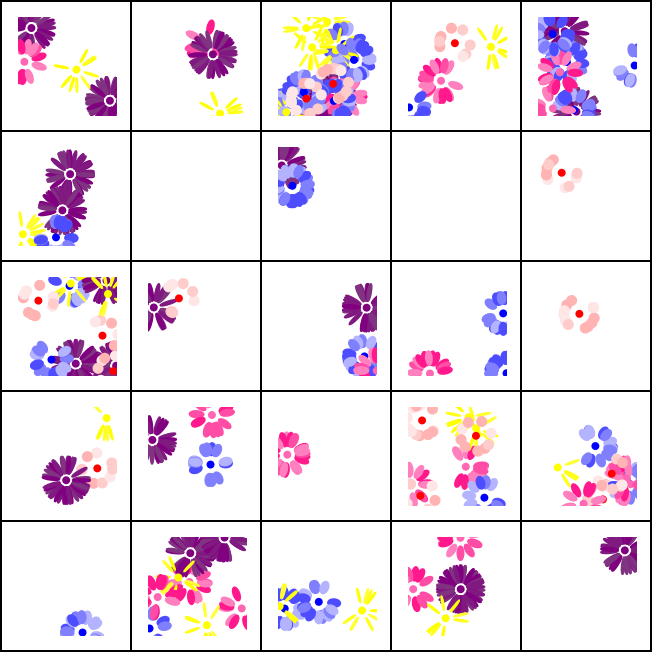

In [36]:
to_imgrid(torch.stack([dataset[i] for i in  range(25)]), nrow=5)

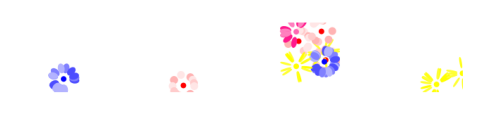

In [39]:

generate_flower_image(num_images=4, image_size=128)

### Encode images into latent space

In [40]:
from os.path import join
import os
from tqdm.auto import tqdm
from diffusers.models import AutoencoderKL
vae = "ema"
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-{vae}").to("cuda")

/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [70]:
total_samples = 10000
transform = transforms.Compose([
    transforms.ToTensor(),  # ensures writable tensor
    transforms.Normalize(0.5, 0.5),
])
device = "cuda"
dataset = FlowerDataset(num_images=total_samples, image_size=128, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=16)
latent_collection = []
for batch in tqdm(dataloader):
    with torch.no_grad():
        latents = vae.encode(batch.to(device)).latent_dist.sample().cpu()
    latent_collection.append(latents)
latent_collection = torch.cat(latent_collection, dim=0)
print(latent_collection.shape)
# save latent collection
# torch.save(latent_collection, "latent_collection.pt")

  0%|          | 0/157 [00:00<?, ?it/s]

torch.Size([10000, 4, 16, 16])


In [74]:

print(latent_collection.shape)
savedir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionAttnConsistency/datasets/"
os.makedirs(savedir, exist_ok=True)
torch.save(latent_collection, join(savedir, "flower_latents10k_pilots.pt"))

torch.Size([10000, 4, 16, 16])


#### Comparison of images and their VAE reconstruction

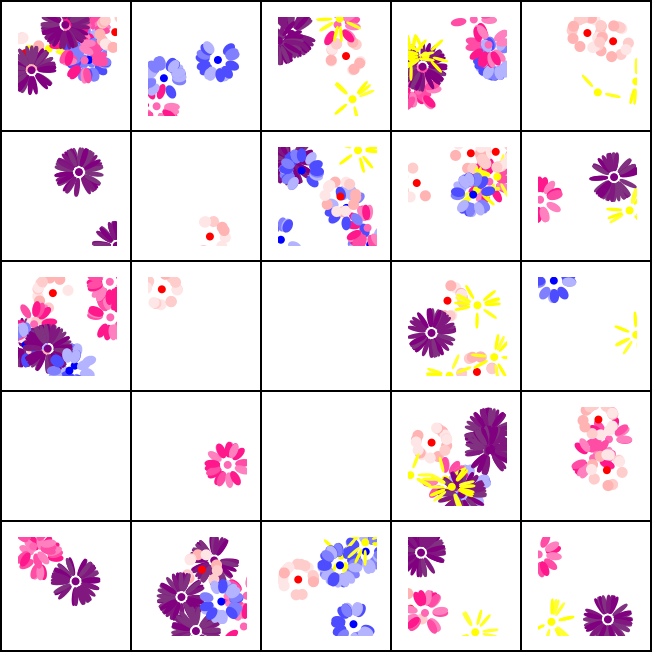

In [68]:
to_imgrid(batch[:25 ] * 0.5 + 0.5, nrow=5)

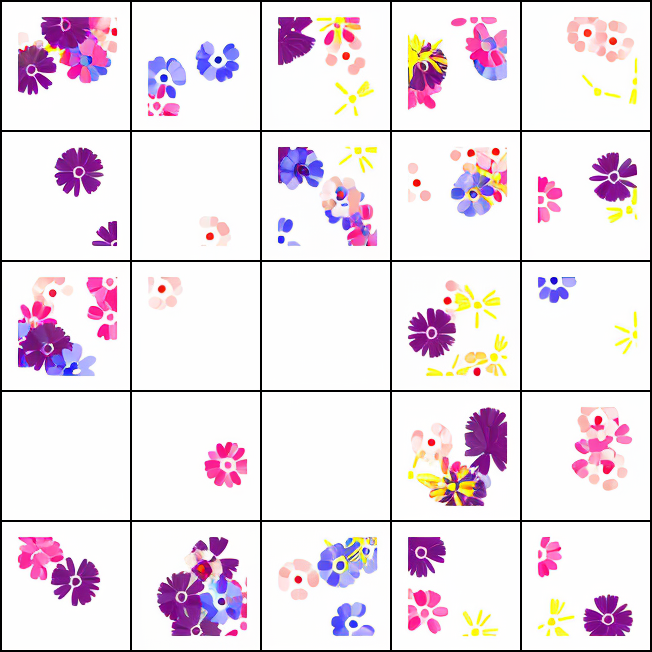

In [65]:
with torch.no_grad():
    sample = vae.decode(latent_collection[0:25].to("cuda")).sample.cpu()
# plt.imshow(sample[0].permute(1, 2, 0) * 0.5 + 0.5)
# plt.axis("off")
sample = (sample * 0.5 + 0.5).clamp(0, 1)
to_imgrid(sample, nrow=5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


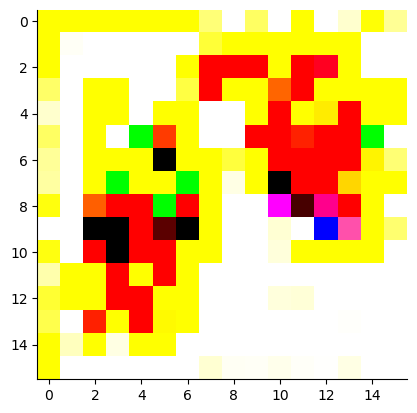

In [54]:
plt.imshow(latent_collection[3][:3].permute(1, 2, 0))

In [45]:
img = dataset[0][None].cuda()
with torch.no_grad():
    print(vae.encode(img).latent_dist.sample().cpu())
    print(vae.encode(img).latent_dist.mean)

tensor([[[[11.3950,  8.8313,  8.7631,  ..., 10.6613,  8.9531,  9.7444],
          [ 8.8356,  8.8068, 10.0996,  ...,  9.6889,  8.8460,  8.5842],
          [ 9.5629, 10.5158,  9.6224,  ...,  9.8816,  9.0864,  8.8373],
          ...,
          [10.5254, 11.4826, 10.0924,  ...,  5.4886,  9.3526,  8.6681],
          [ 9.0714,  8.9730,  9.6332,  ...,  8.8169,  9.5618,  7.8348],
          [ 7.1278,  7.9930,  9.4729,  ...,  8.9798,  7.5174,  8.3689]],

         [[ 7.9279,  6.9589,  6.5437,  ...,  7.4287,  5.8571,  7.6796],
          [ 6.8070,  8.1219,  8.2882,  ...,  5.9407,  5.6101,  8.3391],
          [ 8.4418,  8.1593,  8.0664,  ...,  5.8394,  5.0361,  8.2539],
          ...,
          [ 6.8898,  9.4142,  1.4216,  ..., -0.0508,  6.9199,  7.8361],
          [ 6.7763,  7.3188,  6.5437,  ...,  9.9933,  2.6732,  8.5509],
          [ 8.3448,  7.1293,  7.3798,  ...,  7.4249,  7.7148,  9.6396]],

         [[-2.5237, -0.5350, -0.1678,  ..., -1.1858, -1.0583, -0.5654],
          [ 0.0441,  2.0299,  